In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.6 MB/s eta 0:00:00


In [ ]:
# Cargamos el AE del paso anterior
import torch
import torch.nn as nn

class AutoencoderSC(nn.Module):
    def __init__(self, n_genes=2000):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

In [ ]:
from google.colab import drive
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')

autoencoder = AutoencoderSC(n_genes=2000).to(device)

# Le cargamos los pesos del Drive
ruta_guardado = '/content/drive/MyDrive/pesos_autoencoder.pth'
autoencoder.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación y lo congelamos
autoencoder.eval()
for param in autoencoder.parameters():
    param.requires_grad = False # Congela los pesos,

print("Autoencoder cargado y listo")

Mounted at /content/drive
Autoencoder cargado y listo


In [ ]:
import scanpy as sc
drive.mount('/content/drive')
# Cargamos los datos que guardamos antes
adata_pert = sc.read_h5ad('/content/drive/MyDrive/kang_pbmc_limpio.h5ad')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Queremos demostrar que la IA aprende el "concepto matemático" del Interferón. Por eso le ocultamos todas las Células B estimuladas. La IA aprende qué le hace el Interferón a los Monocitos , Linfocitos ... . Luego, en el test, le damos una Célula B de control (sana) y le decimos: "Aplica lo que has aprendido sobre el Interferón a esta célula que jamás has visto enferma".
Si logra predecir los genes exactos que se encienden en la Célula B, demostramos que ha entendido lo que le hace el interferon a las celulas.


In [ ]:
# Preparamos los datos para el etrenamiento

test_data = adata_pert[(adata_pert.obs['cell_type'] == 'B') & (adata_pert.obs['condition'] == 'stimulated')].copy()
train_data = adata_pert[~((adata_pert.obs['cell_type'] == 'B') & (adata_pert.obs['condition'] == 'stimulated'))].copy()

# Extraer la matriz de genes del train y del test
matriz_genes_train = train_data.X.toarray()
print(f"Tienes {matriz_genes_train.shape[0]} células y {matriz_genes_train.shape[1]} genes para train")
matriz_genes_test = test_data.X.toarray()
print(f"Tienes {matriz_genes_test.shape[0]} células y {matriz_genes_test.shape[1]} genes para test")

from sklearn.preprocessing import LabelEncoder

# Tambien extraemos y traducimos el tipo celular a números (0, 1, 2...) y la condicion
le_tipo = LabelEncoder()
le_cond = LabelEncoder()
etiquetas_tipo = le_tipo.fit_transform(train_data.obs['cell_type'])
etiquetas_cond = le_cond.fit_transform(train_data.obs['condition'])

etiquetas_tipo_test = le_tipo.transform(train_data.obs['cell_type'])
etiquetas_cond_test = le_cond.transform(train_data.obs['condition'])

print(f"Clases a generar ({len(le_tipo.classes_)}): {le_tipo.classes_}")
print(f"Condiciones posibles ({len(le_cond.classes_)}): {le_cond.classes_}")


Tienes 15900 células y 2000 genes para train
Tienes 993 células y 2000 genes para test
Clases a generar (7): ['B' 'CD14+Mono' 'CD4T' 'CD8T' 'Dendritic' 'FCGR3A+Mono' 'NK']
Condiciones posibles (2): ['control' 'stimulated']


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Convertir a tensores y mover a la GPU
X_train_tensor = torch.tensor(matriz_genes_train, dtype=torch.float32).to(device)
y_tipo_train_tensor = torch.tensor(etiquetas_tipo, dtype=torch.long).to(device)
y_cond_train_tensor = torch.tensor(etiquetas_cond, dtype=torch.long).to(device)


X_test_tensor = torch.tensor(matriz_genes_test, dtype=torch.float32).to(device)
y_tipo_test_tensor = torch.tensor(etiquetas_tipo_test, dtype=torch.long).to(device)
y_cond_test_tensor = torch.tensor(etiquetas_cond_test, dtype=torch.long).to(device)

# 2. Pasar por el Encoder (congelado) para obtener el espacio latente
autoencoder.eval()
with torch.no_grad():
    train_latents_raw = autoencoder.encoder(X_train_tensor).cpu().numpy()
    test_latents_raw = autoencoder.encoder(X_test_tensor).cpu().numpy()

# Escalar los latentes (CRÍTICO para la difusión)
scaler_cond = StandardScaler()
train_latents_norm = scaler_cond.fit_transform(train_latents_raw)
test_latents_norm = scaler_cond.transform(test_latents_raw)

# Crear el DataLoader con los 3 elementos: (Latente, Tipo, Condición)
train_z = torch.tensor(train_latents_norm, dtype=torch.float32)
dataset_cond = TensorDataset(train_z, y_tipo_train_tensor, y_cond_train_tensor)
loader_cond = DataLoader(dataset_cond, batch_size=256, shuffle=True)

test_z = torch.tensor(test_latents_norm, dtype=torch.float32)
dataset_test = TensorDataset(test_z, y_tipo_test_tensor, y_cond_test_tensor)
loader_test = DataLoader(dataset_test, batch_size=256, shuffle=False)


Ahora vamos a hacer un modelo que tenga un embedding para el tipo de celula, la t (paso de limpieza) y otro para el estado

In [ ]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.act1 = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.act2 = nn.SiLU()

        # Capa para inyectar el contexto (tiempo + tipo + condicion) en el bloque
        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # El contexto modifica el estado oculto de la célula
        h = self.linear1(x) + self.cond_proj(cond)
        h = self.act1(h)
        h = self.linear2(h)
        return h + x # Conexión residual (suma la entrada original)

class ConditionalLatentDiffusion(nn.Module):
    def __init__(self, latent_dim, num_cell_types, num_conditions, hidden_dim=256, cond_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        # embedding de la t
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU()
        )
        # Embedding del Tipo Celular (Ej. 0=Mono, 1=CD4T, etc.)
        self.type_emb = nn.Embedding(num_cell_types, cond_dim)

        # 3. Embedding de la Condición (Ej. 0=Control, 1=Estimulado)
        self.cond_emb = nn.Embedding(num_conditions, cond_dim)

        # Capa de entrada
        self.init_lin = nn.Linear(latent_dim, hidden_dim)

        # Bloques residuales
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim)
        ])

        # Capa de salida
        self.out_lin = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, t, cell_type_idx, condition_idx):
        # Calculamos los 3 embeddings
        t_emb = self.time_mlp(t)
        type_e = self.type_emb(cell_type_idx)
        cond_e = self.cond_emb(condition_idx)

        # sumamos ,este vector contiene todo el contexto de la célula
        # Matemáticamente: "Paso de ruido T" + "Soy Linfocito B" + "Estoy Estimulado"
        context = t_emb + type_e + cond_e

        # Pasamos la matriz celular por la red
        x = self.init_lin(x_t)

        for block in self.blocks:
            x = block(x, context) # Inyectamos el contexto en cada capa

        # Predecimos el ruido que hay que restar
        ruido_predicho = self.out_lin(x)
        return ruido_predicho

In [ ]:
def train_step_conditional(model, z_0, type_idx, cond_idx, optimizer):
    model.train()
    optimizer.zero_grad()

    device = z_0.device
    batch_size = z_0.shape[0]

    # Tiempo aleatorio para cada célula del batch (t entre 0 y 1)
    t = torch.rand(batch_size, device=device).unsqueeze(1)

    # Ruido puro (Epsilon)
    epsilon = torch.randn_like(z_0).to(device)

    # Aplicar ruido usando el COSINE SCHEDULE
    theta = t * (math.pi / 2)
    alpha_t = torch.cos(theta) # Señal
    sigma_t = torch.sin(theta) # Ruido

    z_t = alpha_t * z_0 + sigma_t * epsilon

    # Predicción del ruido condicionada
    # El modelo recibe: la célula ruidosa, el tiempo, el tipo y la condición
    pred_noise = model(z_t, t.squeeze(), type_idx, cond_idx)

    # 5. Loss: ¿Cuánto se parece el ruido predicho al real?
    loss = nn.MSELoss()(pred_noise, epsilon)

    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
# Inicialización
latent_dim = 128
num_types = 7
num_conds = 2

model = ConditionalLatentDiffusion(latent_dim, num_types, num_conds).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

for epoch in range(500):
    # Entrenamiento
    total_train_loss = 0
    # DataLoader con (z, type, cond)
    for batch_z, batch_types, batch_conds in loader_cond:
        batch_z = batch_z.to(device)
        batch_types = batch_types.to(device)
        batch_conds = batch_conds.to(device)

        loss = train_step_conditional(model, batch_z, batch_types, batch_conds, optimizer)
        total_train_loss += loss

    avg_train_loss = total_train_loss / len(loader_cond)
    # test
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
      for batch_z_test, batch_types_test, batch_conds_test in loader_test:
            batch_z_test = batch_z_test.to(device)
            batch_types_test = batch_types_test.to(device)
            batch_conds_test = batch_conds_test.to(device)

            # Meter ruido paso a paso
            batch_size_test = batch_z_test.shape[0]
            t_test = torch.rand(batch_size_test, device=device).unsqueeze(1)
            epsilon_test = torch.randn_like(batch_z_test).to(device)

            # Geometría del coseno
            theta_test = t_test * (math.pi / 2)
            alpha_t_test = torch.cos(theta_test)
            sigma_t_test = torch.sin(theta_test)

            # Célula con ruido
            z_t_test = alpha_t_test * batch_z_test + sigma_t_test * epsilon_test

            # El modelo predice el ruido
            pred_noise_test = model(z_t_test, t_test.squeeze(), batch_types_test, batch_conds_test)

            # Calculamos el error
            loss_test = criterion(pred_noise_test, epsilon_test)
            total_test_loss += loss_test.item()

    avg_test_loss = total_test_loss / len(loader_test)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

Epoch   0 | Train Loss: 1.0396 | Test Loss: 0.9672
Epoch  20 | Train Loss: 0.3279 | Test Loss: 0.3437
Epoch  40 | Train Loss: 0.3228 | Test Loss: 0.3500
Epoch  60 | Train Loss: 0.3196 | Test Loss: 0.3363
Epoch  80 | Train Loss: 0.3097 | Test Loss: 0.3418
Epoch 100 | Train Loss: 0.3040 | Test Loss: 0.3348
Epoch 120 | Train Loss: 0.2913 | Test Loss: 0.3153
Epoch 140 | Train Loss: 0.2832 | Test Loss: 0.3126
Epoch 160 | Train Loss: 0.2687 | Test Loss: 0.3095
Epoch 180 | Train Loss: 0.2684 | Test Loss: 0.3232
Epoch 200 | Train Loss: 0.2604 | Test Loss: 0.2995
Epoch 220 | Train Loss: 0.2609 | Test Loss: 0.3106
Epoch 240 | Train Loss: 0.2604 | Test Loss: 0.2915
Epoch 260 | Train Loss: 0.2583 | Test Loss: 0.2856
Epoch 280 | Train Loss: 0.2622 | Test Loss: 0.2897
Epoch 300 | Train Loss: 0.2557 | Test Loss: 0.2970
Epoch 320 | Train Loss: 0.2544 | Test Loss: 0.3054
Epoch 340 | Train Loss: 0.2471 | Test Loss: 0.2841
Epoch 360 | Train Loss: 0.2532 | Test Loss: 0.3144
Epoch 380 | Train Loss: 0.2518 

1. Tomamos tus células B estimuladas reales (batch_z_test). El modelo no ha visto estas células en su vida

2. Elegimos un nivel de "suciedad" al azar (el tiempo $t$). Generamos un ruido matemático puro, llamado $\epsilon$ (epsilon_test). Aplicamos fórmulas trigonométricas (los senos y cosenos) para mezclar la célula original con ese ruido. El resultado es $z_t$, una célula borrosa e irreconocible.

3. Le damos al modelo la célula borrosa ($z_t$), el nivel de borrosidad ($t$), y las etiquetas (índices de "célula B" y "estimulada"). basándote en lo que sabes de las B-control y de las otras células estimuladas ¿puedes decirme exactamente qué ruido ensucia esta imagen?"


Si adivina bien el ruido, el Loss es bajo.

Si no tiene ni idea de cómo es una B-estimulada, adivinará mal el ruido y el Loss será alto

In [ ]:
import math
import torch

@torch.no_grad()
def estimular_celulas_sinteticas_guidance(model, latentes_base, tipo_idx, cond_destino_idx, cond_origen_idx, t_start=0.95, num_steps=30, guidance_scale = 3.0):
    model.eval()
    device = latentes_base.device
    num_celulas = latentes_base.shape[0]

    # Etiquetas (Toda la población es tipo B)
    tipos = torch.full((num_celulas,), tipo_idx, dtype=torch.long, device=device)

    # Condición DESTINO (Estimulada) y ORIGEN (Control)
    conds_destino = torch.full((num_celulas,), cond_destino_idx, dtype=torch.long, device=device)
    conds_origen = torch.full((num_celulas,), cond_origen_idx, dtype=torch.long, device=device)

    # Ruido inicial
    t_inicial = torch.full((num_celulas,), t_start, device=device)
    epsilon = torch.randn_like(latentes_base)
    theta_inicial = t_inicial.unsqueeze(1) * (math.pi / 2)
    alpha_inicial = torch.cos(theta_inicial)
    sigma_inicial = torch.sin(theta_inicial)

    z = alpha_inicial * latentes_base + sigma_inicial * epsilon
    tiempos = torch.linspace(t_start, 0.0, num_steps + 1, device=device)

    # Bucle DDIM con Contrastive Guidance
    for i in range(num_steps):
        t_actual = tiempos[i].repeat(num_celulas)
        t_siguiente = tiempos[i+1].repeat(num_celulas)

        theta_actual = t_actual.unsqueeze(1) * (math.pi / 2)
        alpha_actual = torch.cos(theta_actual)
        sigma_actual = torch.sin(theta_actual)

        theta_siguiente = t_siguiente.unsqueeze(1) * (math.pi / 2)
        alpha_siguiente = torch.cos(theta_siguiente)
        sigma_siguiente = torch.sin(theta_siguiente)

        # Predicción como si fuera Control (Origen)
        pred_noise_origen = model(z, t_actual, tipos, conds_origen)

        # Predicción como si fuera Estimulada (Destino)
        pred_noise_destino = model(z, t_actual, tipos, conds_destino)

        # APLICAMOS LA GUÍA
        pred_noise = pred_noise_origen + guidance_scale * (pred_noise_destino - pred_noise_origen)

        z_0_pred = (z - sigma_actual * pred_noise) / alpha_actual
        z = alpha_siguiente * z_0_pred + sigma_siguiente * pred_noise

    return z

In [ ]:
genes_reales_b_control = adata_pert[(adata_pert.obs['cell_type'] == 'B') & (adata_pert.obs['condition'] == 'control')].copy()
genes_reales_b_estimuladas = adata_pert[(adata_pert.obs['cell_type'] == 'B') & (adata_pert.obs['condition'] == 'stimulated')].copy()

# Para generar las predicciones :
# Pasamos a tensor las control:
tensor_control = torch.tensor(genes_reales_b_control.X.toarray(), dtype=torch.float32).to(device)
# Pasamos a espacio latente :
autoencoder.eval()
with torch.no_grad():
    latentes_raw = autoencoder.encoder(tensor_control).cpu().numpy()

# Normalizamos con el scaler que usaste para entrenar la difusión
latentes_norm = scaler_cond.transform(latentes_raw)
latentes_tensor = torch.tensor(latentes_norm, dtype=torch.float32).to(device)


latentes_estimuladas_norm = estimular_celulas_sinteticas_guidance(
    model,
    latentes_base=latentes_tensor,
    tipo_idx=0,            # El índice de tu tipo celular B
    cond_destino_idx=1,    # El índice de "Stimulated"
    cond_origen_idx=0,     # El índice de "Control"
    t_start=0.7,
    num_steps=30,
    guidance_scale= 3.0    # Fuerza del empuje (prueba con 2.0, 3.0 o 4.0)
)

# Deshacemos la normalización
latentes_estimuladas_raw = scaler_cond.inverse_transform(latentes_estimuladas_norm.cpu().numpy())
latentes_estimuladas_tensor = torch.tensor(latentes_estimuladas_raw, dtype=torch.float32).to(device)

# E. Decodificamos de vuelta a 2000 genes
with torch.no_grad():
    genes_fake_b_estimuladas = autoencoder.decoder(latentes_estimuladas_tensor).cpu().numpy()

genes_fake_b_estimuladas[genes_fake_b_estimuladas < 0.05] = 0.0   # sparcity

print(f"Fake Estimuladas Generadas: {genes_fake_b_estimuladas.shape}")

Fake Estimuladas Generadas: (818, 2000)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


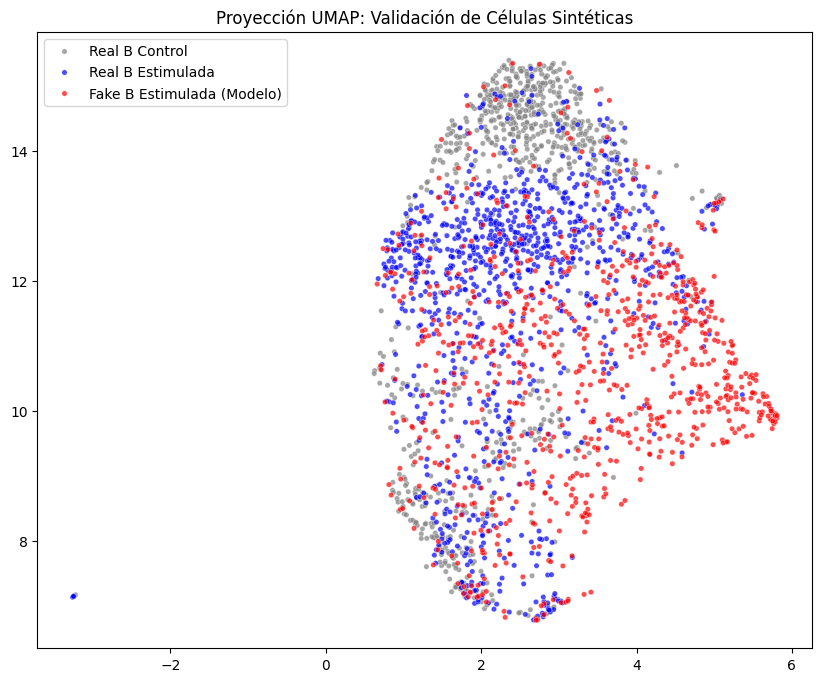

1. Correlación de Pearson (Firma Genética): 0.9509


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy.stats import pearsonr

# Juntamos todo en una sola matriz gigante para que el UMAP calcule el espacio global
X_combined = np.vstack([
    genes_reales_b_control.X.toarray(),
    genes_reales_b_estimuladas.X.toarray(),
    genes_fake_b_estimuladas
])

# Creamos las etiquetas para el gráfico
etiquetas = (
    ['Real B Control'] * len(genes_reales_b_control) +
    ['Real B Estimulada'] * len(genes_reales_b_estimuladas) +
    ['Fake B Estimulada (Modelo)'] * len(genes_fake_b_estimuladas)
)
reductor = umap.UMAP(n_components=2, random_state=42)
embedding = reductor.fit_transform(X_combined)

# Dibujamos el gráfico
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=etiquetas,
    palette={'Real B Control': 'gray', 'Real B Estimulada': 'blue', 'Fake B Estimulada (Modelo)': 'red'},
    alpha=0.7,
    s=15
)
plt.title("Proyección UMAP: Validación de Células Sintéticas")
plt.legend()
plt.show()


# Correlación de Pearson de los perfiles medios
media_real_estimulada = np.mean(genes_reales_b_estimuladas.X.toarray(), axis=0)
media_fake_estimulada = np.mean(genes_fake_b_estimuladas, axis=0)

correlacion, p_value = pearsonr(media_real_estimulada, media_fake_estimulada)
print(f"1. Correlación de Pearson (Firma Genética): {correlacion:.4f}")


In [ ]:
# Cargamos las celulas generadas

ruta_carga = '/content/drive/MyDrive/celulas_B_sinteticas_sanas.npy'
B_sinteticas_control = np.load(ruta_carga)
print(f"¡Células recuperadas del Drive con éxito! Forma: {B_sinteticas_control.shape}")

# pasamos a tensor
B_sinteticas_control = torch.tensor(B_sinteticas_control, dtype=torch.float32).to(device)

with torch.no_grad():
    latentes_control_raw = autoencoder.encoder(B_sinteticas_control)

# Normalizamos (súper importante para que el modelo de difusión no se vuelva loco)
latentes_control_norm = scaler_cond.transform(latentes_control_raw.cpu().numpy())
latentes_control_tensor = torch.tensor(latentes_control_norm, dtype=torch.float32).to(device)

¡Células recuperadas del Drive con éxito! Forma: (1000, 2000)


In [ ]:
# hacemos la prediccion de estimuladas
B_sinteticas_estimuladas = estimular_celulas_sinteticas_guidance(
    model,
    latentes_base=latentes_control_tensor,
    tipo_idx=0,            # El índice de tu tipo celular B
    cond_destino_idx=1,    # El índice de "Stimulated"
    cond_origen_idx=0,     # El índice de "Control"
    t_start=0.7,           # conservamos el 30% de la estructura original de la celula
    num_steps=30,
    guidance_scale= 3.0     # Fuerza del empuje
)

# Deshacemos la normalización
latentes_estimuladas_raw = scaler_cond.inverse_transform(B_sinteticas_estimuladas.cpu().numpy())
latentes_estimuladas_tensor = torch.tensor(latentes_estimuladas_raw, dtype=torch.float32).to(device)

# Decodificamos de vuelta a 2000 genes
with torch.no_grad():
    genes_fake_b_estimuladas = autoencoder.decoder(latentes_estimuladas_tensor).cpu().numpy()

genes_fake_b_estimuladas[genes_fake_b_estimuladas < 0.05] = 0.0   # sparcity

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


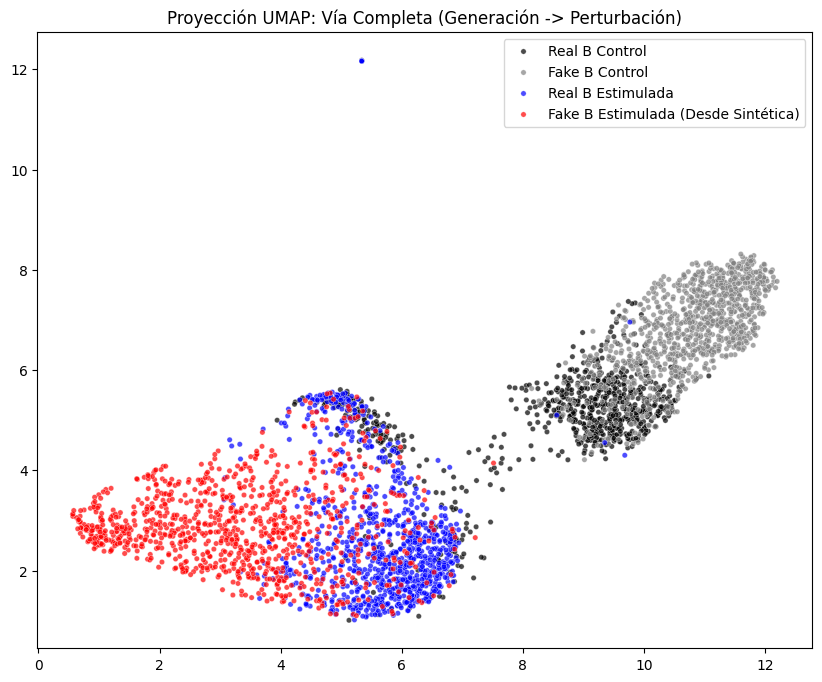

In [ ]:
X_combined = np.vstack([
    genes_reales_b_control.X.toarray(),
    B_sinteticas_control.cpu().numpy(),
    genes_reales_b_estimuladas.X.toarray(),
    genes_fake_b_estimuladas
])

etiquetas = (
    ['Real B Control'] * len( genes_reales_b_control.X.toarray()) +
    ['Fake B Control'] * len( B_sinteticas_control.cpu().numpy()) +
    ['Real B Estimulada'] * len(genes_reales_b_estimuladas.X.toarray()) +
    ['Fake B Estimulada (Desde Sintética)'] * len(genes_fake_b_estimuladas)
)


reductor = umap.UMAP(n_components=2, random_state=42)
embedding = reductor.fit_transform(X_combined)

# GRÁFICO
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=etiquetas,
    palette={'Real B Control' : 'black',
             'Fake B Control': 'gray',
             'Real B Estimulada': 'blue',
             'Fake B Estimulada (Desde Sintética)': 'red'
             },
    alpha=0.7,
    s=15
)
plt.title("Proyección UMAP: Vía Completa (Generación -> Perturbación)")
plt.legend()
plt.show()

Validacion , ahora vamos a entrenar un clasificador unciamente con celulas relaes que clasifique estimuladas y no estimuladas . Posteriormente introducire mis celulas fake estimuladas para ver cuantas clasifica como estimuladas


Resultados sobre 1000 células sintéticas estimuladas testeadas:
Clasificadas como ESTIMULADA (Correcto): 99.90%
Clasificadas como CONTROL (Fallo): 0.10%


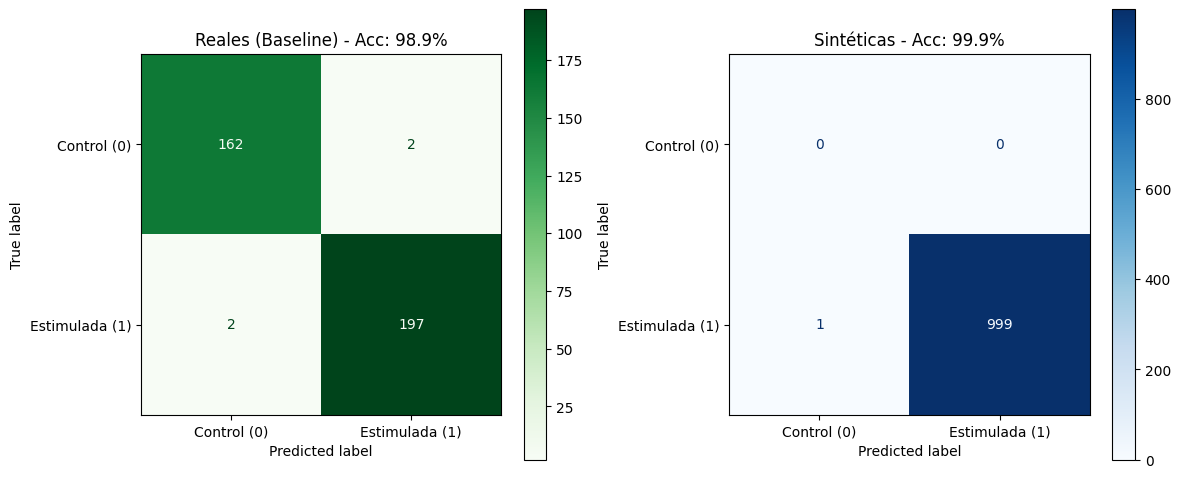

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


X_real = np.vstack([genes_reales_b_control.X.toarray(), genes_reales_b_estimuladas.X.toarray()])
# Etiquetas: 0 para Control (Sana), 1 para Estimulada (Enferma)
y_real = np.array([0] * len(genes_reales_b_control.X.toarray()) + [1] * len(genes_reales_b_estimuladas.X.toarray()))

X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)

rf_juez = RandomForestClassifier(n_estimators=100, random_state=42)
rf_juez.fit(X_train, y_train)

predicciones_fake = rf_juez.predict(genes_fake_b_estimuladas)
predicciones_real = rf_juez.predict(X_test)
# Metricas Real
acc_real = accuracy_score(y_test, predicciones_real)
# MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Matriz Reales
cm_real = confusion_matrix(y_test, predicciones_real, labels=[0, 1])
disp_real = ConfusionMatrixDisplay(confusion_matrix=cm_real, display_labels=['Control (0)', 'Estimulada (1)'])
disp_real.plot(cmap='Greens', ax=axes[0], values_format='d')
axes[0].set_title(f"Reales (Baseline) - Acc: {acc_real * 100:.1f}%")

# Metricas Sinteticas
# Calculamos qué porcentaje el modelo clasificó como 1, estimulada
porcentaje_exito = np.mean(predicciones_fake == 1) * 100
porcentaje_fallo = np.mean(predicciones_fake == 0) * 100

print(f"\nResultados sobre {len(genes_fake_b_estimuladas)} células sintéticas estimuladas testeadas:")
print(f"Clasificadas como ESTIMULADA (Correcto): {porcentaje_exito:.2f}%")
print(f"Clasificadas como CONTROL (Fallo): {porcentaje_fallo:.2f}%")

# Matriz Sintéticas
y_true_sinteticas = np.ones(len(genes_fake_b_estimuladas))
pred_sinteticas = rf_juez.predict(genes_fake_b_estimuladas)
acc_sinteticas = accuracy_score(y_true_sinteticas, pred_sinteticas)

cm_sint = confusion_matrix(y_true_sinteticas, predicciones_fake, labels=[0, 1])
disp_sint = ConfusionMatrixDisplay(confusion_matrix=cm_sint, display_labels=['Control (0)', 'Estimulada (1)'])
disp_sint.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f"Sintéticas - Acc: {porcentaje_exito :.1f}%")

plt.tight_layout()
plt.show()


In [ ]:
# Vamos a hacer lo mismo con celulas no estimuladas fake a ver si las clasifica como reales :

predicciones = rf_juez.predict(B_sinteticas_control.cpu())

# Calculamos qué porcentaje el modelo clasificó como 1, estimulada
porcentaje_exito = np.mean(predicciones == 0) * 100
porcentaje_fallo = np.mean(predicciones == 1) * 100

print(f"\nResultados sobre {len(B_sinteticas_control)} células sintéticas no estimuladas testeadas:")
print(f"Clasificadas como NO ESTIMULADA (Correcto): {porcentaje_exito:.2f}%")
print(f"Clasificadas como ESTIMULADA (Fallo): {porcentaje_fallo:.2f}%")


Resultados sobre 1000 células sintéticas no estimuladas testeadas:
Clasificadas como NO ESTIMULADA (Correcto): 92.80%
Clasificadas como ESTIMULADA (Fallo): 7.20%
